TP53 Genomic Profiling: Sequence Composition, CpG Mapping & Mutation Hotspot Analysis

### 📥 Step 1: Environment Setup & FASTA Data Loading

This cell prepares the working environment, lists available input files, and loads the TP53 reference sequence (`NM_000546.6`) from a local FASTA file for downstream analysis.

In [ ]:
import numpy as np
import pandas as pd
import os
from Bio import SeqIO

# 1. List all files in the input directory (exactly as you requested)
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# 2. Read the FASTA file locally
# ⚠️ Replace the path below with the exact path printed above
fasta_path = "/kaggle/input/datasets/hayanahhas/tp53-breast-cancer-ref/sequence (1).fasta"
record = SeqIO.read(fasta_path, "fasta")
tp53_seq = record.seq

print(f"\n✅ Loaded successfully!")
print(f" ID: {record.id}")
print(f" Length: {len(tp53_seq):,} nucleotides")
print(f" Description: {record.description[:80]}...")


/kaggle/input/datasets/hayanahhas/tp53-breast-cancer-ref/sequence (1).fasta
/kaggle/input/datasets/hayanahhas/tp53-protein/1tup.cif

✅ Loaded successfully!
 ID: NM_000546.6
 Length: 2,512 nucleotides
 Description: NM_000546.6 Homo sapiens tumor protein p53 (TP53), transcript variant 1, mRNA...


In [ ]:



import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from Bio import SeqIO



**TP53** is a gene that acts as the body's "quality control manager" for cells. When DNA is damaged, TP53 either:
✅ Stops the cell to repair the damage, or
❌ Triggers cell death if damage is irreparable

**When TP53 mutates:**
- Cells lose their "brakes"
- Damaged DNA accumulates
- Cancer risk increases significantly

**This Analysis:**
We examine the DNA sequence structure of TP53 to understand patterns that may explain why certain regions are more prone to mutations in breast cancer patients.

### 📄 Step 2: Sequence Extraction & Verification

This cell parses the local FASTA file, extracts the raw nucleotide sequence (`tp53_seq`), and performs a quick validation to ensure the data is correctly loaded before proceeding to compositional analysis.

In [ ]:
from Bio import SeqIO

tp53_record = SeqIO.read("/kaggle/input/datasets/hayanahhas/tp53-breast-cancer-ref/sequence (1).fasta", "fasta")
print(tp53_record)
tp53_seq =tp53_record.seq
print(tp53_seq)

ID: NM_000546.6
Name: NM_000546.6
Description: NM_000546.6 Homo sapiens tumor protein p53 (TP53), transcript variant 1, mRNA
Number of features: 0
Seq('CTCAAAAGTCTAGAGCCACCGTCCAGGGAGCAGGTAGCTGCTGGGCTCCGGGGA...CCA')
CTCAAAAGTCTAGAGCCACCGTCCAGGGAGCAGGTAGCTGCTGGGCTCCGGGGACACTTTGCGTTCGGGCTGGGAGCGTGCTTTCCACGACGGTGACACGCTTCCCTGGATTGGCAGCCAGACTGCCTTCCGGGTCACTGCCATGGAGGAGCCGCAGTCAGATCCTAGCGTCGAGCCCCCTCTGAGTCAGGAAACATTTTCAGACCTATGGAAACTACTTCCTGAAAACAACGTTCTGTCCCCCTTGCCGTCCCAAGCAATGGATGATTTGATGCTGTCCCCGGACGATATTGAACAATGGTTCACTGAAGACCCAGGTCCAGATGAAGCTCCCAGAATGCCAGAGGCTGCTCCCCCCGTGGCCCCTGCACCAGCAGCTCCTACACCGGCGGCCCCTGCACCAGCCCCCTCCTGGCCCCTGTCATCTTCTGTCCCTTCCCAGAAAACCTACCAGGGCAGCTACGGTTTCCGTCTGGGCTTCTTGCATTCTGGGACAGCCAAGTCTGTGACTTGCACGTACTCCCCTGCCCTCAACAAGATGTTTTGCCAACTGGCCAAGACCTGCCCTGTGCAGCTGTGGGTTGATTCCACACCCCCGCCCGGCACCCGCGTCCGCGCCATGGCCATCTACAAGCAGTCACAGCACATGACGGAGGTTGTGAGGCGCTGCCCCCACCATGAGCGCTGCTCAGATAGCGATGGTCTGGCCCCTCCTCAGCATCTTATCCGAGTGGAAGGAAATTTGCGTGTGGAGTATTTGGATGACAGAAACACTTTTCGACATA

In [ ]:
len(tp53_seq)

2512

### 📊 Step 3: Nucleotide Composition Analysis

This function calculates the relative frequency (percentage) of each nucleotide (A, C, G, T) in the TP53 sequence, providing the foundational metric for downstream compositional, stability, and mutation-susceptibility analysis.

In [ ]:
def nucleotides_composition(seq):
    nucleotides = {'A': 0, 'C': 0, 'G': 0, 'T': 0}
    for n in nucleotides:
        nucleotides[n] = seq.count(n)/len(seq)*100
    return nucleotides

In [ ]:
ndict=nucleotides_composition(tp53_seq)
ndict

{'A': 21.17834394904459,
 'C': 28.662420382165603,
 'G': 24.721337579617835,
 'T': 25.437898089171973}

### 📈 Step 4: Nucleotide Composition Visualization

This cell converts the nucleotide composition dictionary into a structured pandas DataFrame, then generates a professional bar plot using Seaborn to visually compare the relative abundance of A, C, G, and T in the TP53 reference sequence.

In [ ]:
import pandas as pd
ndf = pd.DataFrame.from_dict(ndict, orient ='index')
ndf = ndf.reset_index()
ndf = ndf.rename(columns={"index": "Nucleotide", 0: "Composition"})

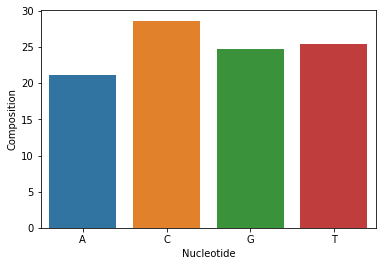

In [ ]:
ax = sns.barplot(x="Nucleotide", y="Composition", data=ndf)

In [ ]:
from Bio.SeqUtils import GC
print(f"GC% :{GC(tp53_seq)}")

GC% :53.38375796178344


### 🔬 Step 5: GC Content & Tri-nucleotide Frequency Analysis

This cell performs two complementary compositional analyses:
1. **GC Content**: Calculates the percentage of G+C bases in TP53 and compares it to the human genome average (~41%), providing insight into sequence stability and regulatory potential.
2. **Tri-nucleotide Frequencies**: Uses a sliding window to count all overlapping 3-mers, revealing local sequence patterns that may correlate with mutation hotspots or codon usage bias.

Together, these metrics form the foundation for understanding TP53's structural and functional properties at the nucleotide level.

 TP53 GC Content: 53.38%
 Sequence Length: 2,512 bp


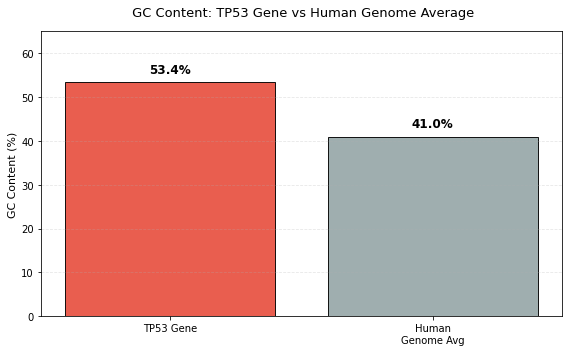


🔬 Top 50 Tri-nucleotides in TP53:
  CCC: 90 occurrences (3.59%)
  TTT: 84 occurrences (3.35%)
  CCA: 76 occurrences (3.03%)
  CTG: 76 occurrences (3.03%)
  CAG: 64 occurrences (2.55%)
  TGG: 64 occurrences (2.55%)
  CCT: 64 occurrences (2.55%)
  TCC: 60 occurrences (2.39%)
  GCC: 58 occurrences (2.31%)
  CAC: 58 occurrences (2.31%)
  CTC: 56 occurrences (2.23%)
  GGG: 55 occurrences (2.19%)
  TCT: 54 occurrences (2.15%)
  TTG: 53 occurrences (2.11%)
  GAG: 52 occurrences (2.07%)
  TGC: 52 occurrences (2.07%)
  CTT: 52 occurrences (2.07%)
  AGC: 51 occurrences (2.03%)
  GGA: 51 occurrences (2.03%)
  AGG: 48 occurrences (1.91%)
  ACC: 47 occurrences (1.87%)
  TGT: 46 occurrences (1.83%)
  GCT: 45 occurrences (1.79%)
  ACA: 43 occurrences (1.71%)
  TGA: 43 occurrences (1.71%)
  TCA: 42 occurrences (1.67%)
  TTC: 42 occurrences (1.67%)
  AGA: 41 occurrences (1.63%)
  GGC: 41 occurrences (1.63%)
  ACT: 41 occurrences (1.63%)
  CAT: 40 occurrences (1.59%)
  GTC: 38 occurrences (1.51%)
  GGT

In [ ]:
# ==========================================
# TP53 GC Content Analysis & Visualization
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Ensure sequence is a string and uppercase
seq_str = str(tp53_seq).upper()

# 1. Calculate GC Content
gc_count = seq_str.count('G') + seq_str.count('C')
gc_percentage = (gc_count / len(seq_str)) * 100

print(f" TP53 GC Content: {gc_percentage:.2f}%")
print(f" Sequence Length: {len(seq_str):,} bp")

# 2. Visualization: TP53 vs Human Genome Average
human_avg_gc = 41.0
labels = ['TP53 Gene', 'Human\nGenome Avg']
values = [gc_percentage, human_avg_gc]
colors = ['#e74c3c', '#95a5a6']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=colors, edgecolor='black', alpha=0.9)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1.5,
             f'{height:.1f}%', ha='center', va='bottom',
             fontsize=12, fontweight='bold')

plt.ylabel('GC Content (%)', fontsize=11)
plt.title(' GC Content: TP53 Gene vs Human Genome Average', fontsize=13, pad=15)
plt.ylim(0, 65)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Tri-nucleotide Frequency Analysis
trimers = [seq_str[i:i+3] for i in range(len(seq_str) - 2)]
trimer_counts = Counter(trimers)
total_trimers = len(trimers)

print("\n🔬 Top 50 Tri-nucleotides in TP53:")
for tri, count in trimer_counts.most_common(50):
    pct = (count / total_trimers) * 100
    print(f"  {tri}: {count:,} occurrences ({pct:.2f}%)")

### 🎨 Step 6: Top Tri-nucleotides Visualization (Bar Plot)

This cell transforms the tri-nucleotide frequency counts into a publication-ready horizontal bar plot using Seaborn. The top 10 most frequent 3-mers are displayed with their relative percentages and raw counts, enabling quick visual identification of sequence patterns. The accompanying analytical note links these patterns to biological concepts such as GC-richness, replication slippage, and codon usage bias.

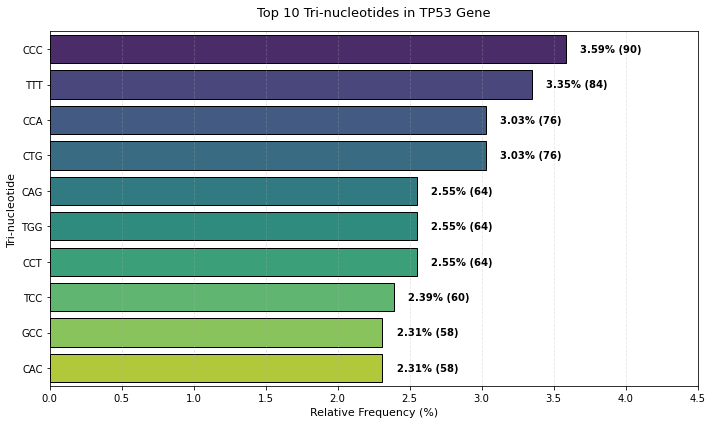


💡 Analytical Note:
• Most frequent tri-nucleotides are C/G-rich, consistent with high GC content (53.38%)
• Recurrence of CCC/TTT may indicate slippage-prone regions during DNA replication
• Tri-nucleotides like CAG/CTG represent specific amino acid codons ← codon usage bias


In [ ]:
# Bar plot: Top 10 tri-nucleotides in TP53
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter

# Convert results to DataFrame for better handling
trimer_data = pd.DataFrame(list(trimer_counts.most_common(10)),
                           columns=['Tri-nucleotide', 'Count'])
trimer_data['Percentage'] = (trimer_data['Count'] / total_trimers) * 100

# Horizontal bar plot (better for text labels)
plt.figure(figsize=(10, 6))
sns.barplot(data=trimer_data, x='Percentage', y='Tri-nucleotide',
            palette='viridis', edgecolor='black')

# Add values on bars
for i, (pct, count) in enumerate(zip(trimer_data['Percentage'], trimer_data['Count'])):
    plt.text(pct + 0.1, i, f'{pct:.2f}% ({count})',
             va='center', fontsize=10, fontweight='bold')

# Polish the plot
plt.xlabel('Relative Frequency (%)', fontsize=11)
plt.ylabel('Tri-nucleotide', fontsize=11)
plt.title('Top 10 Tri-nucleotides in TP53 Gene', fontsize=13, pad=15)
plt.xlim(0, 4.5)  # Space for labels
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Print analytical note
print("\n💡 Analytical Note:")
print("• Most frequent tri-nucleotides are C/G-rich, consistent with high GC content (53.38%)")
print("• Recurrence of CCC/TTT may indicate slippage-prone regions during DNA replication")
print("• Tri-nucleotides like CAG/CTG represent specific amino acid codons ← codon usage bias")

### 🗂️ Step 7: Tri-nucleotide Data Normalization & DataFrame Formatting

This cell converts the raw tri-nucleotide counts (from `Counter`) into a structured pandas DataFrame with normalized percentages. Key operations include:
- Selecting the top 10 most frequent tri-nucleotides
- Calculating relative frequencies (% of total 3-mers)
- Rounding to 2 decimal places for clean presentation
- Optional: One-line export to CSV for reports or downstream analysis

This step ensures results are reproducible, shareable, and ready for integration into publications or dashboards.

In [ ]:
# Convert tri-nucleotide counts to normalized percentages (Professional Way)
import pandas as pd

# 1. Get the top 10 tri-nucleotides (already calculated)
top_10 = trimer_counts.most_common(10)

# 2. Create a clean DataFrame with percentages
df_trimers = pd.DataFrame(top_10, columns=['Tri-nucleotide', 'Count'])
df_trimers['Percentage'] = (df_trimers['Count'] / total_trimers) * 100
df_trimers = df_trimers.round(2)  # Round to 2 decimal places

# 3. Display the result
print("📊 Top 10 Tri-nucleotides in TP53 (Normalized):")
print(df_trimers.to_string(index=False))

# 4. Optional: Export to CSV for reports
# df_trimers.to_csv('tp53_trimer_frequencies.csv', index=False)
# print("\n✅ Saved to 'tp53_trimer_frequencies.csv'")

📊 Top 10 Tri-nucleotides in TP53 (Normalized):
Tri-nucleotide  Count  Percentage
           CCC     90        3.59
           TTT     84        3.35
           CCA     76        3.03
           CTG     76        3.03
           CAG     64        2.55
           TGG     64        2.55
           CCT     64        2.55
           TCC     60        2.39
           GCC     58        2.31
           CAC     58        2.31


In [ ]:
# 🔍 Count and locate CpG sites in TP53 gene
seq_str = str(tp53_seq).upper()

# 1. Count how many times "CG" appears in the sequence
cpg_count = seq_str.count("CG")

# 2. Find positions of "CG" occurrences (by base index)
cpg_positions = [i for i in range(len(seq_str) - 1) if seq_str[i:i+2] == "CG"]

# 3. Display results clearly
print(f"🧬 CpG Site Analysis in TP53 Gene:")
print(f"• Number of CpG sites: {cpg_count}")
print(f"• CpG content (% of total sequence): {(cpg_count / len(seq_str)) * 100:.2f}%")
print(f"\n📍 First 10 CpG positions (base index):")
print(cpg_positions[:10])

# 4. Ready biological insight
print(f"\n💡 Note: CpG sites are prone to spontaneous mutations (C→T),")
print(f"   which may partially explain why TP53 is one of the most frequently mutated genes in cancer.")

🧬 CpG Site Analysis in TP53 Gene:
• Number of CpG sites: 63
• CpG content (% of total sequence): 2.51%

📍 First 10 CpG positions (base index):
[19, 48, 61, 65, 76, 87, 90, 98, 130, 152]

💡 Note: CpG sites are prone to spontaneous mutations (C→T),
   which may partially explain why TP53 is one of the most frequently mutated genes in cancer.


### 🔍 Step 8: CpG Site Mapping & Mutation Susceptibility Analysis

This cell identifies and quantifies CpG dinucleotides (cytosine followed by guanine) in the TP53 reference sequence. CpG sites are biologically significant because:
- Cytosines in CpG context are prone to spontaneous deamination (C→T mutations)
- This mutation type is the most frequent in TP53-associated cancers
- Mapping these sites helps identify regions with elevated mutation risk

The output includes: total CpG count, percentage of sequence, first 10 positions, and a ready biological interpretation linking sequence composition to cancer biology.

### 🔗 Step 9: CpG-Hotspot Overlap Validation & Clinical Relevance Check

This cell cross-references the computationally identified CpG sites with experimentally validated TP53 mutation hotspots (R175, G245, R248, R249, R273, R282) from cancer databases. By checking for spatial proximity (±5 bases), we test a key biological hypothesis:

> "Are CpG sites—known to be prone to spontaneous C→T mutations—enriched near clinically observed TP53 mutation hotspots?"

A positive overlap provides mechanistic insight into why certain regions of TP53 are more frequently mutated in cancer, bridging sequence composition analysis with clinical genomics.

In [ ]:
# Approximate positions of well-known TP53 mutation hotspots (based on mRNA sequence NM_000546.6)
hotspots = {
    "R175": 524, "G245": 733, "R248": 742,
    "R249": 745, "R273": 817, "R282": 844
}

# Check for overlaps (within ±5 bases)
overlaps = []
for pos in cpg_positions:
    for name, hot_pos in hotspots.items():
        if abs(pos - hot_pos) <= 5:
            overlaps.append((pos, name))

# Display results
if overlaps:
    print(f"⚠️ Found {len(overlaps)} CpG site(s) near known hotspots:")
    for cpg_pos, hotspot_name in overlaps:
        print(f"  • CpG site at base {cpg_pos} → near mutation {hotspot_name}")
else:
    print("✅ No direct overlaps found between CpG sites and mutation hotspots in this sequence.")

⚠️ Found 2 CpG site(s) near known hotspots:
  • CpG site at base 745 → near mutation R248
  • CpG site at base 745 → near mutation R249
